# Chapter 18: The Hierarchy
A total and its stores cannot independently be right if they do not add up.
We reconcile a seeded synthetic two-store system with bottom-up and MinT.
The covariance matrix comes from earlier errors, never from the evaluation set.

In [1]:
from pathlib import Path
import sys
project = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
rng=begin(18)
S=np.array([[1.,1.],[1.,0.],[0.,1.]])

## Three forecasts, two independent quantities
Rows of S represent national total, store A and store B. Forecasts made at
each level have different errors; the demonstration deliberately exposes this.

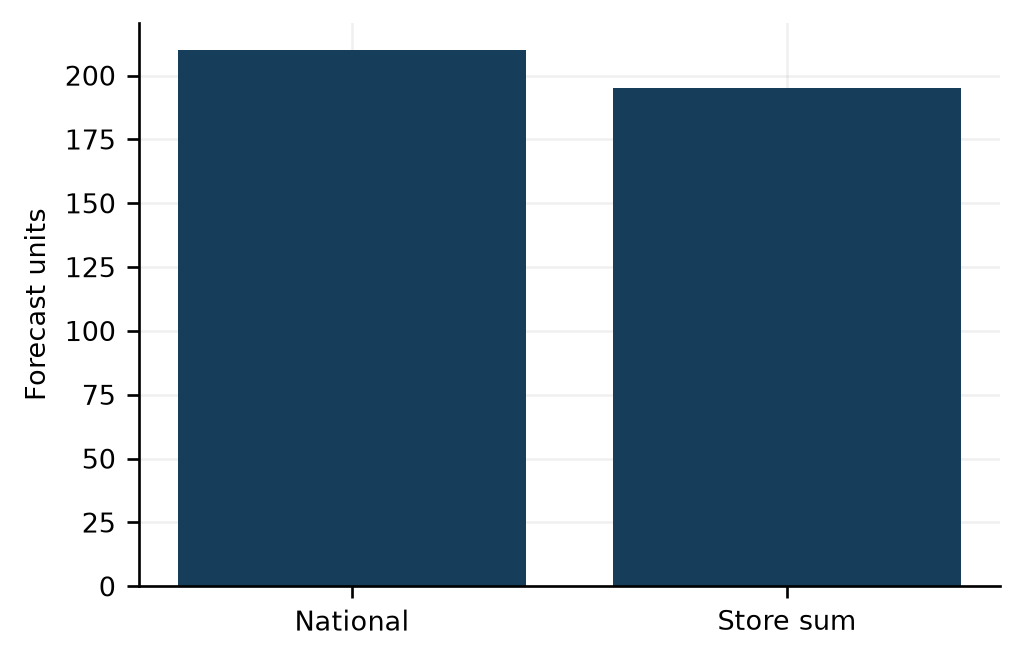

In [2]:
base=np.array([210.,90.,105.])
plt.figure(); plt.bar(['National','Store sum'],[base[0],base[1:].sum()]); plt.ylabel('Forecast units')
save(18,1,'The forecasts do not add up','Illustrative forecasts: the independently forecast national total differs from the sum of stores.','## Section One: The Forecasts That Didn\'t Add Up')

## MinT is a covariance-weighted projection
Reconciliation maps base forecasts to S G y. The inverse covariance gives less
weight to noisy directions. Shrinkage toward a diagonal stabilizes the estimate.

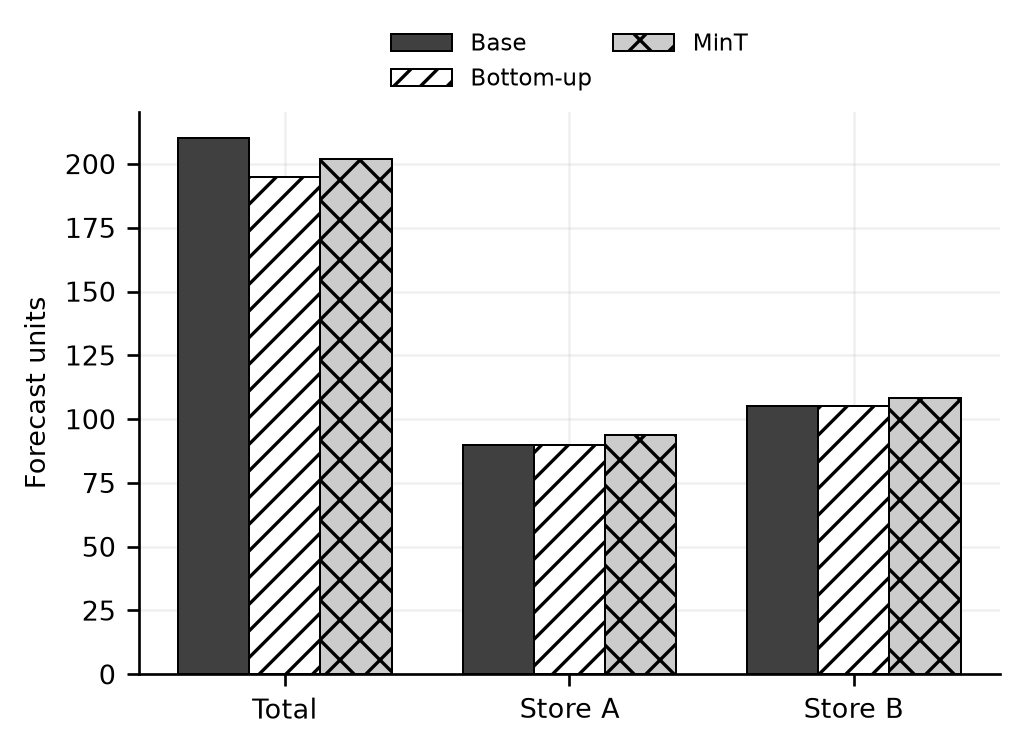

In [3]:
cov=np.array([[64.,12.,8.],[12.,36.,4.],[8.,4.,25.]])
past_errors=rng.multivariate_normal(np.zeros(3),cov,size=180)
W=np.cov(past_errors,rowvar=False)
W=.8*W+.2*np.diag(np.diag(W))
Winv=np.linalg.inv(W)
G=np.linalg.solve(S.T@Winv@S,S.T@Winv)
mint=S@G@base; bottom=S@base[1:]
assert np.allclose(mint[0],mint[1:].sum())
assert np.allclose(S@G@S,S)
plt.figure(); x=np.arange(3)
for offset,values,label in [(-.25,base,'Base'),(0,bottom,'Bottom-up'),(.25,mint,'MinT')]:
    plt.bar(x+offset,values,width=.25,label=label)
plt.xticks(x,['Total','Store A','Store B']); plt.ylabel('Forecast units'); plt.legend()
save(18,2,'Reconciliation changes all levels','Synthetic example. MinT uses the estimated error covariance to project the base forecasts onto coherent totals.','## Section Three: The MinT Solution')

## Coherence is guaranteed; accuracy is measured
A new set of errors is drawn independently of the covariance training sample.
This repeated-experiment evaluation is not a claim about any actual retailer.

Base [8.56889092 6.45796825 5.04659975]
Bottom-up [8.63265063 6.45796825 5.04659975]
MinT [6.92597503 5.71269481 4.58652381]


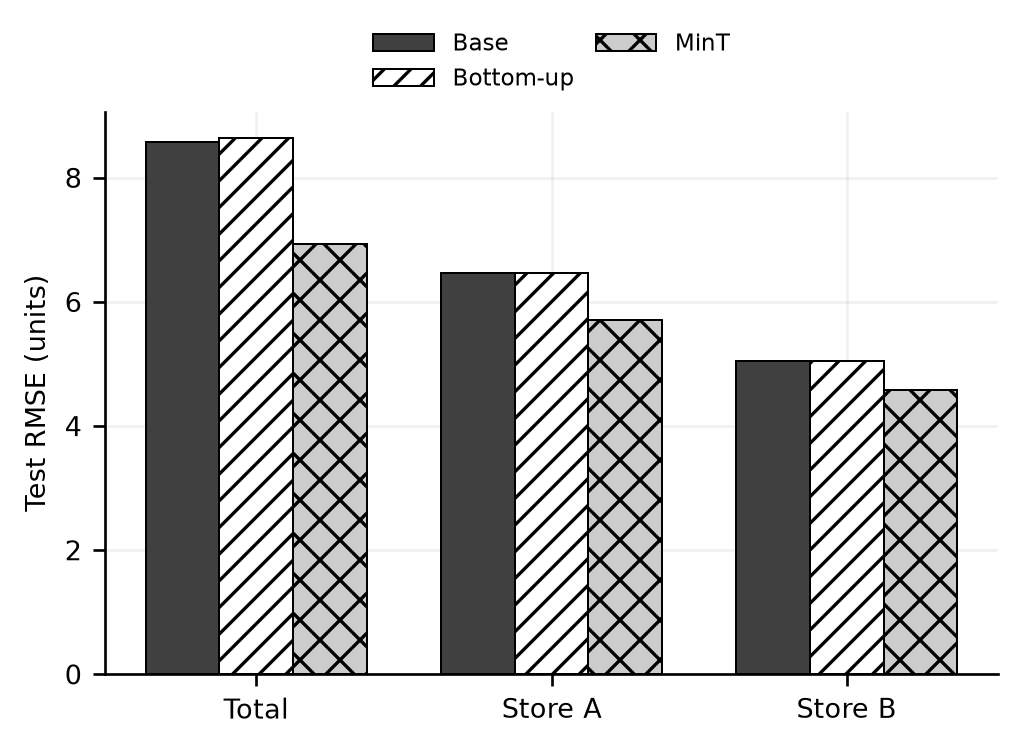

In [4]:
truth_bottom=rng.uniform(60,120,(400,2)); truth=truth_bottom@S.T
base_test=truth+rng.multivariate_normal(np.zeros(3),cov,size=400)
predictions={'Base':base_test,'Bottom-up':base_test[:,1:]@S.T,'MinT':base_test@G.T@S.T}
plt.figure()
for offset,(name,pred) in zip([-.25,0,.25],predictions.items()):
    err=np.sqrt(np.mean((pred-truth)**2,axis=0)); print(name,err)
    plt.bar(x+offset,err,width=.25,label=name)
    if name!='Base': assert np.allclose(pred[:,0],pred[:,1:].sum(axis=1))
plt.xticks(x,['Total','Store A','Store B']); plt.ylabel('Test RMSE (units)'); plt.legend()
save(18,3,'Accuracy across the hierarchy','Independent synthetic evaluation cases. Reconciliation guarantees coherence, while these errors measure accuracy under the specified error process.','## Section Four: The Full Methodology')

## Limits and exercise
Change store error correlation and covariance sample size. Does MinT still help?
Nonnegativity is not guaranteed by unconstrained MinT. For operational series,
estimate W from rolling-origin errors and verify the hierarchy has no double counting.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
Long format, one row per node and period: `node,timestamp,target`, with every node on an identical calendar and historical values that already add up within `history_tolerance`. The hierarchy is declared in config as `edges`, a list of `[child, parent]` pairs; the tool builds the summing matrix itself (aggregates first, leaves last). The older `node,forecast` input with a supplied `S` is still accepted for a one-shot reconciliation of forecasts you already hold.

Minimal **format illustration**, not sufficient training data:

```csv
node,timestamp,target
Total,2010-01-01,100.7
A,2010-01-01,60.4
B,2010-01-01,40.3
Total,2010-02-01,105.9
A,2010-02-01,63.1
B,2010-02-01,42.8
```

## Explain the mechanism

Reconciliation projects conflicting forecasts onto the space where totals equal their parts. Bottom-up trusts the detailed forecasts; OLS spreads discrepancies geometrically; MinT weights directions by their forecast-error covariance.

## Work through the arithmetic

For total 210 and stores 90,105, the discrepancy is 15. Bottom-up sets total to 195 and retains stores. Equal-weight OLS adds 5 to each store and subtracts 5 from total, giving [205,95,110]. These values are coherent because 95+110=205; their accuracy still needs actual outcomes.

## Adapt the lesson to reader data

Replace S, base and historical error construction. Keep historical covariance data separate from test errors. The original source demonstrates bottom-up and MinT; if OLS is absent in the current lesson, add a W=I comparison in the applied copy rather than claiming the chart already contains it.

For this chapter, settle these questions before fitting: What are the bottom-level quantities and summing relationships? Do nodes overlap? Are base forecasts for the same origin/horizon? Are historical forecast errors available to estimate covariance?

## Interpret the actual lesson outputs

The 210-versus-195 example demonstrates inconsistency. The projection assertions check coherence and identity on already coherent vectors. Independent synthetic test errors assess accuracy under one known covariance process, not a retailer’s real distribution.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `node,timestamp,base,bottom_up,OLS,MinT`.
- `summary.json`: `nodes,leaves,S,selected,shrinkage,error_rows,holdout,leaderboard,coherence_max_abs_residual,pool,horizon` plus method, interpretation, assumptions, not_done and status.

The tool builds S from `edges`, forecasts every node with the companion engine (default `pool: smoothing`; `full` and `arima` are available), takes each node's base-forecast errors from the engine's own validation origins, shrinks their covariance toward the diagonal by `shrinkage` (default 0.2), and reconciles by bottom-up, OLS and MinT. Coherence is asserted for every reconciled column. Every method, including the unreconciled base, is scored per node on the untouched final holdout, so the leaderboard shows whether reconciliation helped this hierarchy rather than assuming it. `coherent_quantiles: true` reconciles 500 joint draws when every node's model has intervals and returns MinT q10/q50/q90. MinT is dropped, and reported under `not_done`, when fewer than n_nodes+2 matched errors exist or the covariance is not positive definite. Nonnegativity is not enforced. When the history is too short to hold the engine's rolling origins twice over (for monthly data with a 12-step horizon, fewer than 84 observations), the tool still reconciles the production forecasts but skips the holdout leaderboard, takes the error covariance from the engine's own rolling origins, returns `status: provisional` and says so under `not_done`. The tool runs only when asked; the assistant decides, with the reader, whether the method fits before running it.

## Decide what the evidence supports

Check matrix conditioning, covariance sample size and sensitivity to shrinkage. MinT rests on estimated error structure. Nonnegative operational quantities may require a separately implemented constrained method; clipping node forecasts independently breaks coherence.

Without past errors, use bottom-up or clearly labeled OLS, not fabricated MinT covariance. If hierarchy mapping is ambiguous, return inconsistencies before fitting. If constraints are required but unsupported, report infeasibility rather than hiding negative nodes.

The applied deliverable must make these items inspectable: `results.csv` columns: `node,timestamp,base,bottom_up,OLS,MinT`; `summary.json` keys: `nodes,leaves,S,selected,shrinkage,error_rows,holdout,leaderboard,coherence_max_abs_residual,pool,horizon` plus method, interpretation, assumptions, not_done and status. Quote the holdout leaderboard beside the reconciled forecasts; a coherent forecast that lost accuracy on the holdout is a finding, not a success.

## Three exercises with worked solutions

### Exercise 1

Base [100,40,50]: bottom-up result?

**Worked solution.** [90,40,50].

### Exercise 2

No historical errors are available. Can W=I be called empirically estimated MinT?

**Worked solution.** No. Label it OLS/unweighted reconciliation; empirical covariance was not estimated.

### Exercise 3

A negative bottom node is clipped to zero without changing total. What can fail?

**Worked solution.** Coherence. Enforce nonnegativity jointly or disclose that a constrained reconciliation is needed.

## Business-reader application

Use this request with the skill:

> Use chapter 18 to reconcile hierarchy.csv using the supplied summing matrix, compare eligible methods and verify coherence without claiming accuracy from addition alone.

## Real-data boundary

The [data registry](../data/registry.json) and [data notes](../data/README.md) distinguish bundled observations from controlled fixtures. No matching observed-data application is claimed for this chapter. Supply the chapter-specific records and their provenance before treating the exercise as business evidence; an observed outcome table is not automatically a historical forecast journal or identified experiment.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [5]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch18.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch18.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(18, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch18-workshop-results.csv', index=False)
_ = (workshop_output/'ch18-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: Hierarchical reconciliation (bottom-up, OLS, MinT) over engine base forecasts
Status: passed

Interpretation: On the final 12-step holdout, OLS had the lowest mean MAE across 3 nodes (1.287 vs base 1.287). MinT used a shrunk covariance from 36 validation errors per node. Coherence holds exactly for every reconciled column; accuracy gains must be judged on the holdout, not assumed.

Assumptions:
  - Tree hierarchy with one parent per node
  - Base forecasts unbiased for MinT to dominate
  - Error covariance shrunk toward its diagonal with lambda 0.2
  - Historical values coherent within tolerance
Not done:
  - Coherent quantiles not requested (set coherent_quantiles: true)

Evidence:
  nodes: [Total, A, B]
  leaves: [A, B]
  S: <3 rows>
  selected: <3 entries>
  shrinkage: 0.2
  error_rows: 36
  holdout: <4 entries>
  leaderboard: [OLS, base, MinT, bottom_up]
  coherence_max_abs_residual: 2.842e-14
  pool: smoothing
  horizon: 12

Table: 36 rows, columns ['node', 'timestamp', 'b